# Vietnamese HTR: Missing Paper Components

Notebook này thêm các phần bạn nói là chưa có trong paper:

1. Data Augmentation (single-op, p=0.5)
2. Test Time Augmentation (TTA) + LM rescoring
3. Text label preprocessing + lexicon/OOV
4. Synthetic data generation pipeline
5. So sánh kích thước ảnh notebook vs paper

## Cell 1 - Config tổng
Cấu hình ngắn gọn:
- Aug: p=0.5, shear ±0.35, rotation ±2.5
- TTA: 16 biến thể (4x4), shear ±0.35, rotation ±2.0
- Label mặc định: lowercase, giữ dấu câu
- Mục tiêu: an toàn cho dấu tiếng Việt

### Khác paper như nào?
- Ngôn ngữ: paper dùng English IAM; notebook này tối ưu cho tiếng Việt.
- Shear: paper mạnh hơn (±0.6); bản này giảm còn ±0.35 để đỡ méo dấu thanh.
- TTA: paper dùng shear/rotation; bản này giữ ý tưởng nhưng giảm biên độ shear/rotation để ổn định với chữ có dấu.
- Label preprocessing: paper thiên về chuẩn hóa mạnh; bản này mặc định giữ dấu câu để khớp nhãn thực tế tiếng Việt.
- Language model: paper tham chiếu corpus tiếng Anh; bản này khuyến nghị KenLM 4-gram tiếng Việt.
- Kích thước ảnh: notebook đang theo thiết lập dữ liệu hiện tại (64x2048), khác paper (100x960).

In [10]:
from pathlib import Path
import json
import random
import re
from collections import Counter

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Optional libs (augmentation + LM)
try:
    import albumentations as A
except Exception:
    A = None

ROOT = Path.cwd()
TRAIN_MANIFEST = ROOT / "train" / "manifest.json"
VAL_MANIFEST = ROOT / "validation" / "manifest.json"
TEST_MANIFEST = ROOT / "test" / "manifest.json"

# Current notebook setting vs paper setting
NOTEBOOK_IMAGE_SIZE = (64, 2048)   # (H, W)
PAPER_IMAGE_SIZE = (100, 960)      # (H, W)

# VN-safe preset: keep Vietnamese marks, reduce aggressive deformation
VN_SAFE_CONFIG = {
    "aug": {
        "p_apply": 0.5,
        "shear_range": (-0.35, 0.35),
        "rotation_range": (-2.5, 2.5),
        "elastic_sigma": [3, 4],
        "elastic_alpha": [15, 20],
        "geometric_distort_limit": 0.08,
        "geometric_perspective_scale": (0.02, 0.05),
    },
    "tta": {
        "num_shear": 4,
        "num_rot": 4,
        "shear_range": (-0.35, 0.35),
        "rotation_range": (-2.0, 2.0),
        "lambda": 1.0,
        "omega": 0.25,
    },
    "label": {
        "lowercase": True,
        "remove_punctuation": False,
    },
}

print(f"ROOT: {ROOT}")
print(f"Notebook image size: {NOTEBOOK_IMAGE_SIZE}")
print(f"Paper image size:    {PAPER_IMAGE_SIZE}")
print(f"Albumentations available: {A is not None}")
print("VN-safe config loaded.")

ROOT: d:\ki8\xla\project\dataset\dataset_TV\UIT_HWDB_line\UIT_HWDB_line\split_by_folder_70_15_15_processed
Notebook image size: (64, 2048)
Paper image size:    (100, 960)
Albumentations available: False
VN-safe config loaded.


## Cell 2 - Load manifest và thống kê nhãn
Ý nghĩa:
- Nạp train/validation/test
- In thống kê nhanh độ dài dòng, chữ hoa, dấu câu để chọn cấu hình phù hợp tiếng Việt

In [11]:
def load_manifest(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def flatten_entries(manifest_obj):
    out = []
    for sample in manifest_obj:
        for item in sample.get("images", []):
            out.append(item)
    return out


train_entries = flatten_entries(load_manifest(TRAIN_MANIFEST))
val_entries = flatten_entries(load_manifest(VAL_MANIFEST))
test_entries = flatten_entries(load_manifest(TEST_MANIFEST))

print(f"Train lines: {len(train_entries)}")
print(f"Val lines:   {len(val_entries)}")
print(f"Test lines:  {len(test_entries)}")

# Quick Vietnamese label diagnostics
all_texts = [x["text"] for x in train_entries + val_entries + test_entries]
num_upper = sum(any(ch.isupper() for ch in t) for t in all_texts)
num_punct = sum(bool(re.search(r"[^\w\s]", t, flags=re.UNICODE)) for t in all_texts)

print(f"Lines containing uppercase: {num_upper}/{len(all_texts)}")
print(f"Lines containing punctuation: {num_punct}/{len(all_texts)}")

Train lines: 4993
Val lines:   1181
Test lines:  1055
Lines containing uppercase: 5088/7229
Lines containing punctuation: 6513/7229


## Cell 3 - Data Augmentation Việt-safe
Cấu hình:
- Mỗi ảnh tối đa 1 phép
- Xác suất áp dụng: p=0.5
- Shear ±0.35 (giảm méo dấu)
- Rotation ±2.5
- Elastic sigma {3,4}, alpha {15,20}
- Geometric giảm cường độ

In [12]:
# --- Data Augmentation (VN-safe) ---
# Rule: each image gets at most 1 transform, with total probability p=0.5


def shear_image(img: np.ndarray, k: float):
    h, w = img.shape[:2]
    # x' = x + k*y
    M = np.array([[1.0, k, 0.0], [0.0, 1.0, 0.0]], dtype=np.float32)
    new_w = int(w + abs(k) * h)
    sheared = cv2.warpAffine(
        img,
        M,
        (new_w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=255,
    )
    # Back to original width for stable training shape
    sheared = cv2.resize(sheared, (w, h), interpolation=cv2.INTER_LINEAR)
    return sheared


def rotate_image(img: np.ndarray, angle_deg: float):
    h, w = img.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    rotated = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=255,
    )
    return rotated


def elastic_image(img: np.ndarray, sigma: int, alpha: int):
    if A is None:
        return img
    aug = A.ElasticTransform(alpha=float(alpha), sigma=float(sigma), p=1.0)
    return aug(image=img)["image"]


def geometric_image(img: np.ndarray):
    if A is None:
        return img
    # Reduced distortion strength for Vietnamese diacritics safety
    aug = A.OneOf(
        [
            A.OpticalDistortion(distort_limit=VN_SAFE_CONFIG["aug"]["geometric_distort_limit"], p=1.0),
            A.GridDistortion(num_steps=5, distort_limit=VN_SAFE_CONFIG["aug"]["geometric_distort_limit"], p=1.0),
            A.Perspective(scale=VN_SAFE_CONFIG["aug"]["geometric_perspective_scale"], p=1.0),
        ],
        p=1.0,
    )
    return aug(image=img)["image"]


def apply_single_aug_paper(img: np.ndarray, p_apply: float = None):
    if p_apply is None:
        p_apply = VN_SAFE_CONFIG["aug"]["p_apply"]

    if random.random() > p_apply:
        return img, "none"

    op = random.choice(["shear", "rotation", "elastic", "geometric"])

    if op == "shear":
        lo, hi = VN_SAFE_CONFIG["aug"]["shear_range"]
        k = random.uniform(lo, hi)
        return shear_image(img, k), f"shear(k={k:.3f})"

    if op == "rotation":
        lo, hi = VN_SAFE_CONFIG["aug"]["rotation_range"]
        theta = random.uniform(lo, hi)
        return rotate_image(img, theta), f"rotation(theta={theta:.2f})"

    if op == "elastic":
        sigma = random.choice(VN_SAFE_CONFIG["aug"]["elastic_sigma"])
        alpha = random.choice(VN_SAFE_CONFIG["aug"]["elastic_alpha"])
        return elastic_image(img, sigma, alpha), f"elastic(sigma={sigma}, alpha={alpha})"

    return geometric_image(img), "geometric(distort/stretch/perspective)"

## Cell 4 - Visual kiểm tra augment
Ý nghĩa:
- Hiển thị ảnh gốc + 5 biến thể augment
- Dùng để kiểm tra trực quan dấu tiếng Việt còn đọc được hay không

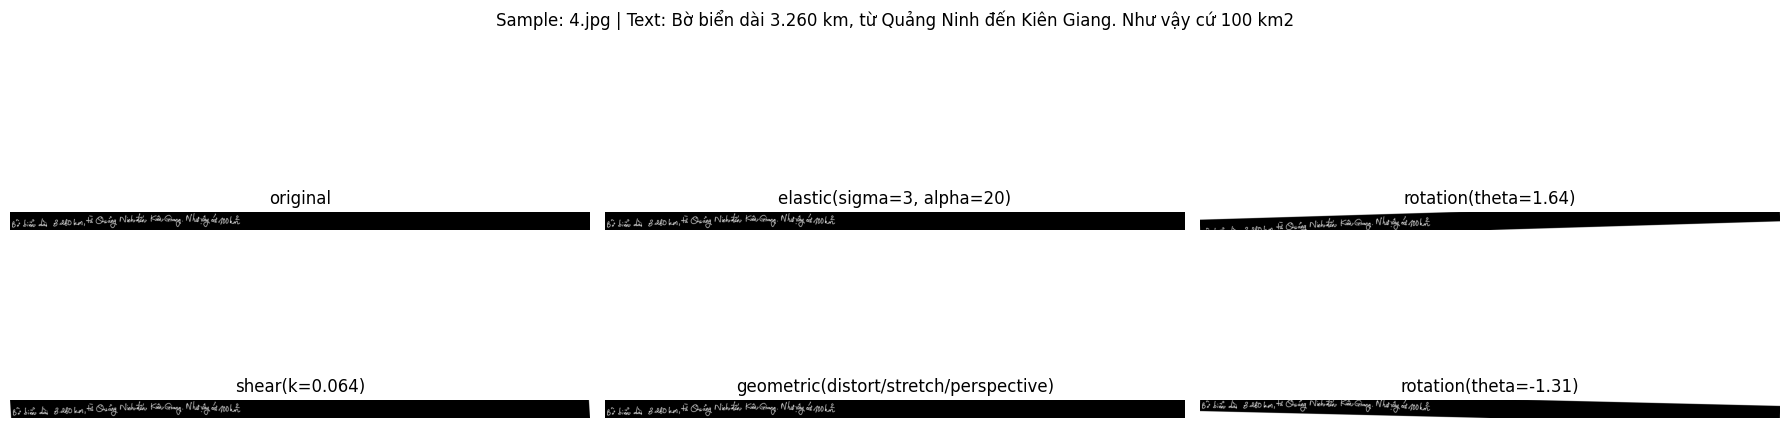

In [13]:
# Visual check: sample one line image and render multiple random augmented outputs

sample_item = random.choice(train_entries)
sample_img_path = ROOT / sample_item["image"]

img = cv2.imread(str(sample_img_path), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(sample_img_path)

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
axes = axes.ravel()

axes[0].imshow(img, cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")

for i in range(1, 6):
    aug_img, aug_name = apply_single_aug_paper(img, p_apply=1.0)
    axes[i].imshow(aug_img, cmap="gray")
    axes[i].set_title(aug_name)
    axes[i].axis("off")

plt.suptitle(f"Sample: {sample_item['image_name']} | Text: {sample_item['text'][:80]}")
plt.tight_layout()
plt.show()

## Cell 5 - TTA Việt-safe
Cấu hình:
- 16 biến thể (4 shear x 4 rotation)
- Shear ±0.35, rotation ±2.0
- Score: lambda*optical + omega*LM
- Khuyến nghị LM: KenLM 4-gram tiếng Việt

In [14]:
# --- Test Time Augmentation (TTA) VN-safe ---
# 16 variants from shear + rotation at inference time.
# score = lambda * optical_score + omega * lm_score


def build_tta_variants(num_shear=None, num_rot=None):
    if num_shear is None:
        num_shear = VN_SAFE_CONFIG["tta"]["num_shear"]
    if num_rot is None:
        num_rot = VN_SAFE_CONFIG["tta"]["num_rot"]

    sh_lo, sh_hi = VN_SAFE_CONFIG["tta"]["shear_range"]
    rt_lo, rt_hi = VN_SAFE_CONFIG["tta"]["rotation_range"]

    shear_vals = np.linspace(sh_lo, sh_hi, num_shear)
    rot_vals = np.linspace(rt_lo, rt_hi, num_rot)
    variants = []
    for k in shear_vals:
        for th in rot_vals:
            variants.append((float(k), float(th)))
    return variants


TTA_VARIANTS = build_tta_variants()
print(f"Num TTA variants: {len(TTA_VARIANTS)}")


def apply_tta_variant(img: np.ndarray, k: float, theta: float):
    out = shear_image(img, k)
    out = rotate_image(out, theta)
    return out


def decode_with_tta(
    img,
    optical_decode_fn,
    lm_score_fn=None,
    lam=None,
    omega=None,
    variants=TTA_VARIANTS,
):
    """
    optical_decode_fn(image) -> (text, optical_score)
    lm_score_fn(text) -> lm_score (optional)
    """
    if lam is None:
        lam = VN_SAFE_CONFIG["tta"]["lambda"]
    if omega is None:
        omega = VN_SAFE_CONFIG["tta"]["omega"]

    best = {"text": "", "score": -1e18, "optical": None, "lm": None, "variant": None}

    for k, th in variants:
        aug = apply_tta_variant(img, k, th)
        text, optical_score = optical_decode_fn(aug)
        lm_score = lm_score_fn(text) if lm_score_fn is not None else 0.0
        total = lam * float(optical_score) + omega * float(lm_score)

        if total > best["score"]:
            best = {
                "text": text,
                "score": total,
                "optical": optical_score,
                "lm": lm_score,
                "variant": (k, th),
            }

    return best


# Dummy example API to demonstrate call contract
def dummy_optical_decode_fn(image):
    # Replace by your OCR model decode
    return "dummy text", -1.0


def dummy_lm_score_fn(text):
    # Replace by KenLM 4-gram score (Vietnamese corpus)
    return -0.5


# _best = decode_with_tta(img, dummy_optical_decode_fn, dummy_lm_score_fn)
# print(_best)

Num TTA variants: 16


## Cell 6 - Label preprocessing + OOV
Cấu hình mặc định:
- lowercase = True
- remove_punctuation = False
- So sánh thêm mode paper-like để bạn đối chiếu nhanh

In [15]:
# --- Text label preprocessing + lexicon/OOV (VN-safe default) ---


def normalize_text(text: str, lowercase=None, remove_punctuation=None):
    if lowercase is None:
        lowercase = VN_SAFE_CONFIG["label"]["lowercase"]
    if remove_punctuation is None:
        remove_punctuation = VN_SAFE_CONFIG["label"]["remove_punctuation"]

    out = text.strip()
    if lowercase:
        out = out.lower()
    if remove_punctuation:
        out = re.sub(r"[^\w\s]", " ", out, flags=re.UNICODE)
        out = re.sub(r"\s+", " ", out).strip()
    return out


def tokenize(text: str):
    return [tok for tok in text.split(" ") if tok]


def build_lexicon(entries, lowercase=None, remove_punctuation=None):
    lex = set()
    for e in entries:
        norm = normalize_text(e["text"], lowercase=lowercase, remove_punctuation=remove_punctuation)
        lex.update(tokenize(norm))
    return lex


def compute_oov_rate(entries, lexicon, lowercase=None, remove_punctuation=None):
    total_tokens = 0
    oov_tokens = 0
    for e in entries:
        toks = tokenize(normalize_text(e["text"], lowercase=lowercase, remove_punctuation=remove_punctuation))
        total_tokens += len(toks)
        oov_tokens += sum(t not in lexicon for t in toks)
    return (oov_tokens / max(total_tokens, 1), oov_tokens, total_tokens)


# Strategy VN-safe (default): lowercase + keep punctuation
train_lex_vn = build_lexicon(train_entries)
val_oov_vn = compute_oov_rate(val_entries, train_lex_vn)
test_oov_vn = compute_oov_rate(test_entries, train_lex_vn)

# Strategy paper-like: lowercase + remove punctuation
train_lex_paper = build_lexicon(train_entries, lowercase=True, remove_punctuation=True)
val_oov_paper = compute_oov_rate(val_entries, train_lex_paper, lowercase=True, remove_punctuation=True)
test_oov_paper = compute_oov_rate(test_entries, train_lex_paper, lowercase=True, remove_punctuation=True)

print("VN-safe default (keep punctuation):")
print(f"  Lexicon size: {len(train_lex_vn)}")
print(f"  Val OOV:  {val_oov_vn[0]:.4%} ({val_oov_vn[1]}/{val_oov_vn[2]})")
print(f"  Test OOV: {test_oov_vn[0]:.4%} ({test_oov_vn[1]}/{test_oov_vn[2]})")

print("\nPaper-like (remove punctuation):")
print(f"  Lexicon size: {len(train_lex_paper)}")
print(f"  Val OOV:  {val_oov_paper[0]:.4%} ({val_oov_paper[1]}/{val_oov_paper[2]})")
print(f"  Test OOV: {test_oov_paper[0]:.4%} ({test_oov_paper[1]}/{test_oov_paper[2]})")

VN-safe default (keep punctuation):
  Lexicon size: 4086
  Val OOV:  2.0850% (395/18945)
  Test OOV: 3.0305% (506/16697)

Paper-like (remove punctuation):
  Lexicon size: 2548
  Val OOV:  1.0927% (202/18486)
  Test OOV: 1.6084% (261/16227)


## Cell 7 - Synthetic data (TRDG)
Thông số gợi ý ngắn gọn:
- Dùng corpus tiếng Việt + font hỗ trợ đầy đủ dấu
- Bắt đầu 50k mẫu để test pipeline
- Tăng dần quy mô khi chất lượng ổn

In [16]:
# --- Synthetic data generation scaffold (TRDG) ---
# Paper-like idea: pretrain on large synthetic corpus, then finetune on real data.

SYNTH_OUT = ROOT / "synthetic_trdg"
SYNTH_OUT.mkdir(exist_ok=True)

# You can expand this with your own Vietnamese corpus file.
vn_seed_texts = [
    "khái quát về biển đảo việt nam",
    "nước ta giáp với biển đông ở hai phía đông và nam",
    "bờ biển dài 3.260 km từ quảng ninh đến kiên giang",
    "mưu sinh dưới đáy biển",
]

corpus_file = ROOT / "vn_corpus_for_trdg.txt"
with corpus_file.open("w", encoding="utf-8") as f:
    for line in vn_seed_texts:
        f.write(line + "\n")

print(f"Saved starter corpus: {corpus_file}")
print("TRDG example command (run in terminal):")
print(
    "trdg -i "
    f"\"{corpus_file}\" "
    f"-o \"{SYNTH_OUT}\" "
    "-c 50000 --language vi --format 32 --extension jpg"
)
print("\nNote: to approach paper scale, increase corpus + handwritten fonts + sample count.")

Saved starter corpus: d:\ki8\xla\project\dataset\dataset_TV\UIT_HWDB_line\UIT_HWDB_line\split_by_folder_70_15_15_processed\vn_corpus_for_trdg.txt
TRDG example command (run in terminal):
trdg -i "d:\ki8\xla\project\dataset\dataset_TV\UIT_HWDB_line\UIT_HWDB_line\split_by_folder_70_15_15_processed\vn_corpus_for_trdg.txt" -o "d:\ki8\xla\project\dataset\dataset_TV\UIT_HWDB_line\UIT_HWDB_line\split_by_folder_70_15_15_processed\synthetic_trdg" -c 50000 --language vi --format 32 --extension jpg

Note: to approach paper scale, increase corpus + handwritten fonts + sample count.


## Cell 8 - Export dataset mới
Cấu hình export:
- Folder output: đổi tại biến OUTPUT_FOLDER_NAME
- Augment chỉ áp dụng cho train
- Validation/Test giữ nguyên
- Ghi aug_op vào manifest để trace

In [17]:
# --- Build and save new dataset folder ---
# Train: apply VN-safe augmentation policy (single-op, p=0.5)
# Validation/Test: keep unchanged (copy)

import shutil
from copy import deepcopy

# Doi ten folder rieng tai day, vi du: "vn_safe_aug_run_01"
OUTPUT_FOLDER_NAME = "vn_safe_aug_run_01"
NEW_DATASET_ROOT = ROOT.parent / OUTPUT_FOLDER_NAME

APPLY_AUG_ON_SPLIT = {"train": True, "validation": False, "test": False}
AUG_P = VN_SAFE_CONFIG["aug"]["p_apply"]


def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)


def process_split(manifest_path: Path, split_name: str):
    data = load_manifest(manifest_path)
    out_data = deepcopy(data)

    for sample_idx, sample in enumerate(data):
        for img_idx, item in enumerate(sample.get("images", [])):
            src = ROOT / item["image"]
            dst = NEW_DATASET_ROOT / item["image"]
            ensure_dir(dst.parent)

            img = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise FileNotFoundError(f"Missing image: {src}")

            aug_name = "none"
            out_img = img
            if APPLY_AUG_ON_SPLIT.get(split_name, False):
                out_img, aug_name = apply_single_aug_paper(img, p_apply=AUG_P)

            ok = cv2.imwrite(str(dst), out_img)
            if not ok:
                raise RuntimeError(f"Cannot write image: {dst}")

            # Keep schema, append metadata for traceability
            out_data[sample_idx]["images"][img_idx]["aug_op"] = aug_name
            out_data[sample_idx]["images"][img_idx]["aug_policy"] = "vn_safe_single_op_p0.5"

    out_manifest = NEW_DATASET_ROOT / split_name / "manifest.json"
    ensure_dir(out_manifest.parent)
    with out_manifest.open("w", encoding="utf-8") as f:
        json.dump(out_data, f, ensure_ascii=False, indent=2)

    return len(out_data), sum(len(s.get("images", [])) for s in out_data)


# Fresh rebuild: remove old folder if exists, then regenerate
if NEW_DATASET_ROOT.exists():
    shutil.rmtree(NEW_DATASET_ROOT)
ensure_dir(NEW_DATASET_ROOT)

summary = {}
summary["train"] = process_split(TRAIN_MANIFEST, "train")
summary["validation"] = process_split(VAL_MANIFEST, "validation")
summary["test"] = process_split(TEST_MANIFEST, "test")

print(f"Saved new dataset at: {NEW_DATASET_ROOT}")
print(f"Aug config: shear={VN_SAFE_CONFIG['aug']['shear_range']}, rot={VN_SAFE_CONFIG['aug']['rotation_range']}, p={AUG_P}")
for k, (num_samples, num_images) in summary.items():
    print(f"{k}: samples={num_samples}, images={num_images}, augmented={APPLY_AUG_ON_SPLIT[k]}")

# Optional: copy report files for reference
for report_name in ["work_summary.json", "duplicates_report.json"]:
    src_report = ROOT / report_name
    if src_report.exists():
        shutil.copy2(src_report, NEW_DATASET_ROOT / report_name)

print("Done.")

Saved new dataset at: d:\ki8\xla\project\dataset\dataset_TV\UIT_HWDB_line\UIT_HWDB_line\vn_safe_aug_run_01
Aug config: shear=(-0.35, 0.35), rot=(-2.5, 2.5), p=0.5
train: samples=179, images=4993, augmented=True
validation: samples=38, images=1181, augmented=False
test: samples=38, images=1055, augmented=False
Done.
